<a href="https://colab.research.google.com/github/sidhantmaurya/machine-learning-algos/blob/main/Phone_addiction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
test= pd.read_csv("/content/test.csv")
train= pd.read_csv("/content/train.csv")
samp= pd.read_csv("/content/sample_submission.csv")

In [ ]:
test.head(5)

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
0,691369,30.0,9.34,NaN,0.77,4.09,7.15,153.0,16.0,NaN,Other,Medium,Yes
1,691370,NaN,NaN,1.91,NaN,1.20,8.67,239.0,148.0,10.68,Female,High,No
2,691371,26.0,8.48,3.64,NaN,3.39,7.47,106.0,123.0,NaN,Male,NaN,No
3,691372,20.0,8.37,2.99,1.69,2.53,5.45,178.0,55.0,9.88,Male,High,Yes
4,691373,25.0,8.25,4.02,1.21,2.32,8.46,63.0,86.0,10.72,Male,Low,No


1.first i have to rename all column
2.covert academic into bool
3. id ka koi kaam nahi hai drop it
4. nan value ko handel karna hai
5.

Which age group is addicted?
Does more screen time increase addiction?
Does sleep affect addiction?
Does exercise reduce addiction?
Are males more addicted?

In [ ]:
train.head(5)

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1.0
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0.0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0.0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1.0
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1.0


In [ ]:
train.columns.tolist()

['id',
 'age',
 'daily_screen_time_hours',
 'social_media_hours',
 'gaming_hours',
 'work_study_hours',
 'sleep_hours',
 'notifications_per_day',
 'app_opens_per_day',
 'weekend_screen_time',
 'gender',
 'stress_level',
 'academic_work_impact',
 'addicted_label']

In [ ]:
test.columns.tolist() # used to get the columns names in an array form

['id',
 'age',
 'daily_screen_time_hours',
 'social_media_hours',
 'gaming_hours',
 'work_study_hours',
 'sleep_hours',
 'notifications_per_day',
 'app_opens_per_day',
 'weekend_screen_time',
 'gender',
 'stress_level',
 'academic_work_impact']

test dont have addicted_label column

In [ ]:
train.size

460922

In [ ]:
train.shape

(32923, 14)

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32923 entries, 0 to 32922
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       32923 non-null  int64  
 1   age                      31561 non-null  float64
 2   daily_screen_time_hours  28355 non-null  float64
 3   social_media_hours       26500 non-null  float64
 4   gaming_hours             26867 non-null  float64
 5   work_study_hours         30542 non-null  float64
 6   sleep_hours              30784 non-null  float64
 7   notifications_per_day    29656 non-null  float64
 8   app_opens_per_day        29016 non-null  float64
 9   weekend_screen_time      27670 non-null  float64
 10  gender                   31605 non-null  object 
 11  stress_level             30266 non-null  object 
 12  academic_work_impact     30788 non-null  object 
 13  addicted_label           32922 non-null  float64
dtypes: float64(10), int64(

In [ ]:
test.size

432536

In [ ]:
test.shape

(33272, 13)

In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33272 entries, 0 to 33271
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       33272 non-null  int64  
 1   age                      31337 non-null  float64
 2   daily_screen_time_hours  29654 non-null  float64
 3   social_media_hours       27800 non-null  float64
 4   gaming_hours             26589 non-null  float64
 5   work_study_hours         30228 non-null  float64
 6   sleep_hours              30776 non-null  float64
 7   notifications_per_day    29473 non-null  float64
 8   app_opens_per_day        30443 non-null  float64
 9   weekend_screen_time      27503 non-null  float64
 10  gender                   31678 non-null  object 
 11  stress_level             31030 non-null  object 
 12  academic_work_impact     30409 non-null  object 
dtypes: float64(9), int64(1), object(3)
memory usage: 3.3+ MB


In [ ]:
display(test,test.describe(include='all'))

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
0,691369,30.0,9.34,NaN,0.77,4.09,7.15,153.0,16.0,NaN,Other,Medium,Yes
1,691370,NaN,NaN,1.91,NaN,1.20,8.67,239.0,148.0,10.68,Female,High,No
2,691371,26.0,8.48,3.64,NaN,3.39,7.47,106.0,123.0,NaN,Male,NaN,No
3,691372,20.0,8.37,2.99,1.69,2.53,5.45,178.0,55.0,9.88,Male,High,Yes
4,691373,25.0,8.25,4.02,1.21,2.32,8.46,63.0,86.0,10.72,Male,Low,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33267,724636,25.0,11.58,4.98,3.40,3.00,8.42,118.0,117.0,15.74,Other,Low,Yes
33268,724637,28.0,4.36,0.20,1.92,1.68,7.28,177.0,103.0,6.30,Female,Low,No
33269,724638,23.0,9.28,5.44,0.67,1.11,7.70,111.0,169.0,12.30,Male,Medium,Yes
33270,724639,21.0,6.69,NaN,2.36,0.97,6.40,79.0,104.0,NaN,Male,Medium,Yes


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
count,33272.000000,31337.000000,29654.000000,27800.000000,26589.000000,30228.000000,30776.000000,29473.000000,30443.000000,27503.000000,31678,31030,30409
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,3,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Male,High,Yes
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10697,10657,15465
mean,708004.500000,26.622810,7.640960,2.463142,1.455474,2.364172,6.799605,146.064601,102.449299,9.469267,NaN,NaN,NaN
std,9604.943415,5.164271,2.723927,1.314588,0.939261,1.252906,1.232708,65.776366,48.249602,2.854640,NaN,NaN,NaN
min,691369.000000,18.000000,0.500000,0.010000,0.000000,0.030000,4.500000,20.000000,15.000000,0.820000,NaN,NaN,NaN
25%,699686.750000,22.000000,5.460000,1.440000,0.690000,1.360000,5.770000,94.000000,63.000000,7.260000,NaN,NaN,NaN
50%,708004.500000,27.000000,7.790000,2.300000,1.320000,2.190000,6.800000,150.000000,104.000000,9.570000,NaN,NaN,NaN
75%,716322.250000,31.000000,9.850000,3.350000,2.090000,3.190000,7.860000,204.000000,145.000000,11.750000,NaN,NaN,NaN


In [ ]:
train.isnull().sum()

,0
id,0
age,1362
daily_screen_time_hours,4568
social_media_hours,6423
gaming_hours,6056
work_study_hours,2381
sleep_hours,2139
notifications_per_day,3267
app_opens_per_day,3907
weekend_screen_time,5253


In [ ]:
test.isnull().sum()

,0
id,0
age,1935
daily_screen_time_hours,3618
social_media_hours,5472
gaming_hours,6683
work_study_hours,3044
sleep_hours,2496
notifications_per_day,3799
app_opens_per_day,2829
weekend_screen_time,5769


This helps identify:

Binary features
Low-cardinality categorical columns
Potential ID-like columns

In [ ]:
train.nunique()

,0
id,32923
age,19
daily_screen_time_hours,1186
social_media_hours,648
gaming_hours,400
work_study_hours,591
sleep_hours,451
notifications_per_day,231
app_opens_per_day,166
weekend_screen_time,1246


# New Section
Histogram

Boxplot

Countplot

Heatmap

Pairplot

Correlation Matrix

In [ ]:
train.dtypes

,0
id,int64
age,float64
daily_screen_time_hours,float64
social_media_hours,float64
gaming_hours,float64
work_study_hours,float64
sleep_hours,float64
notifications_per_day,float64
app_opens_per_day,float64
weekend_screen_time,float64


In [ ]:
test.dtypes

,0
id,int64
age,float64
daily_screen_time_hours,float64
social_media_hours,float64
gaming_hours,float64
work_study_hours,float64
sleep_hours,float64
notifications_per_day,float64
app_opens_per_day,float64
weekend_screen_time,float64


In [ ]:
train['addicted_label'].value_counts(normalize=True)#This tells us whether the dataset is balanced.

,proportion
addicted_label,
1.0,0.705941
0.0,0.294059


In [ ]:
train.duplicated().sum()

np.int64(0)

Numerical data


age

daily_screen_time_hours

social_media_hours

gaming_hours

work_study_hours

sleep_hours

notifications_per_day

app_opens_per_day

weekend_screen_time

Catogerical data

gender

stress_level

academic_work_impact

EDA


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

Target distribution

<function matplotlib.pyplot.show(close=None, block=None)>

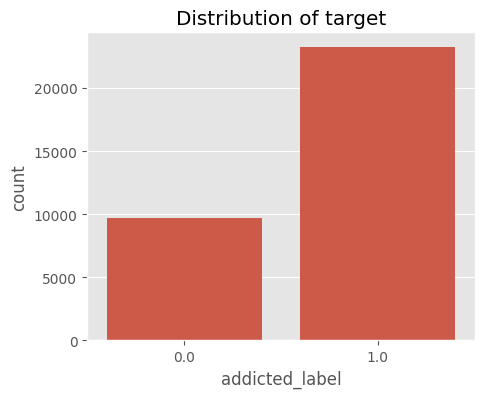

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(data=train,x="addicted_label")
plt.title("Distribution of target")
plt.show

missing value

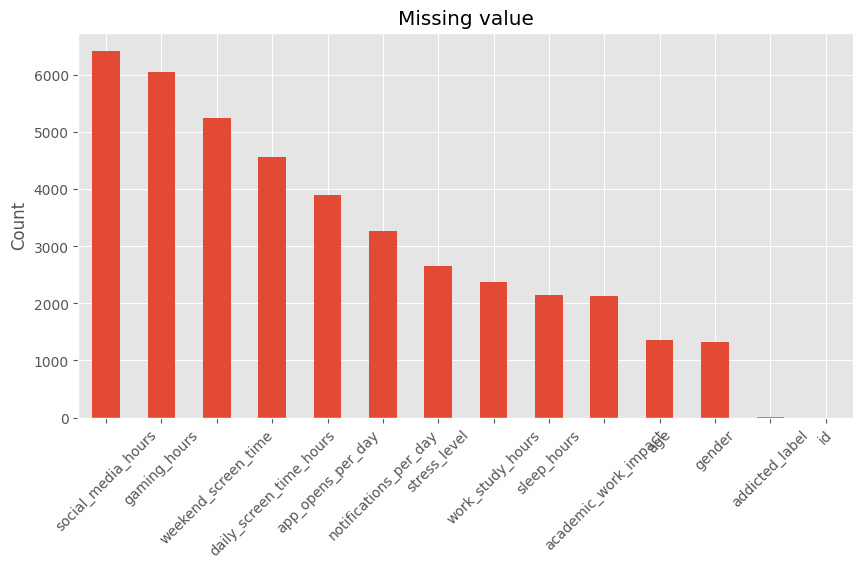

In [ ]:
missing= train.isnull().sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
missing.plot(kind="bar")
plt.title("Missing value")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Histograms of Numerical Features

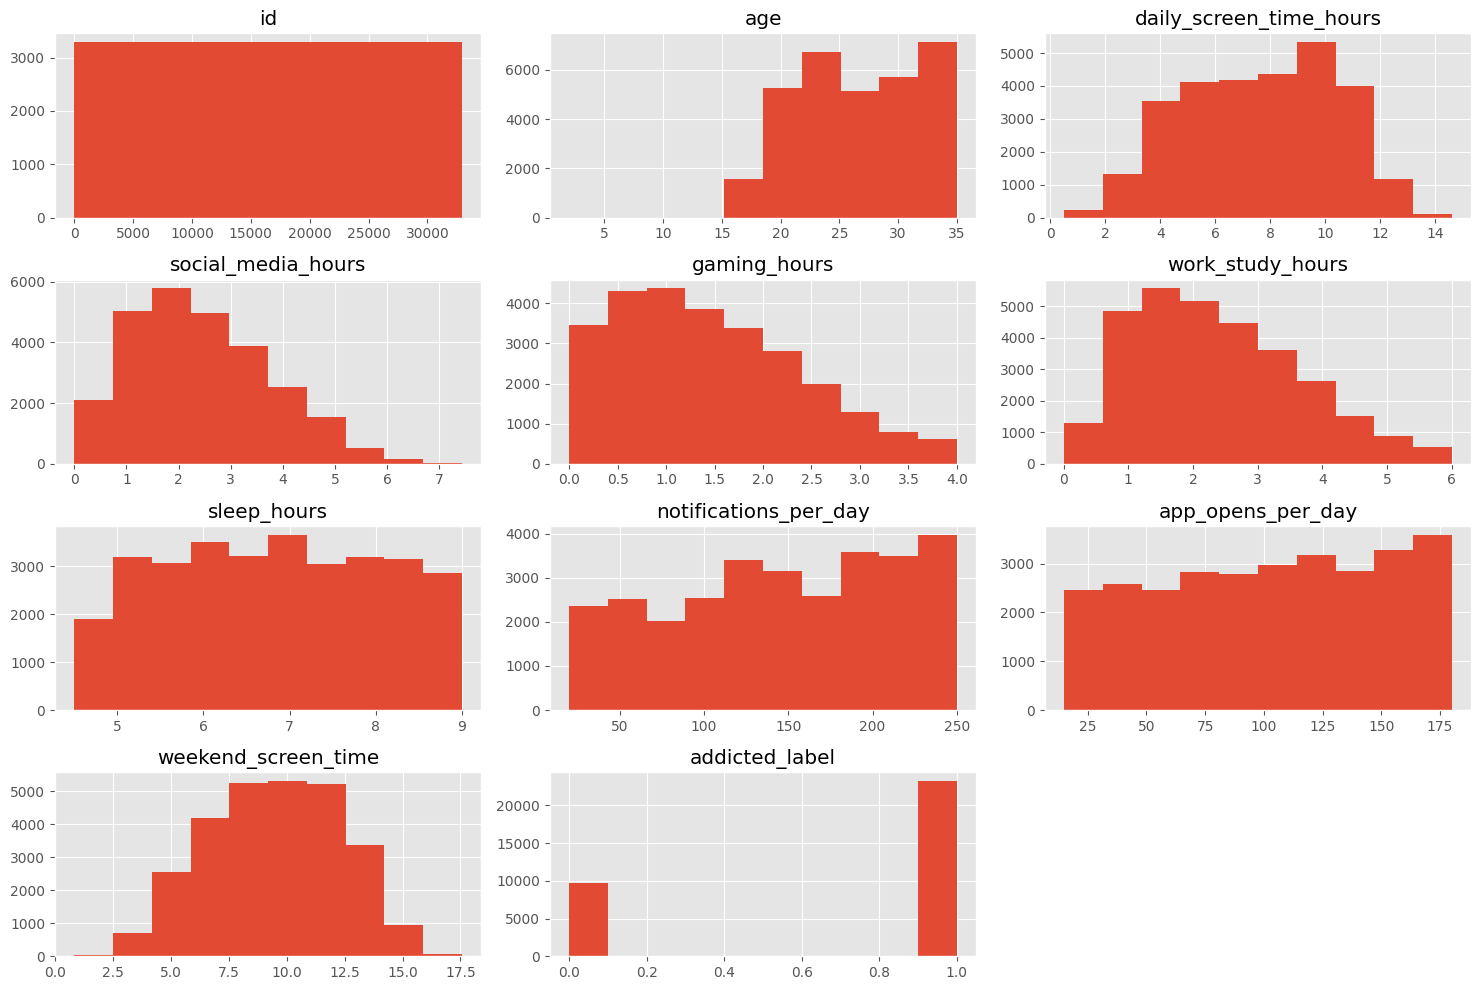

In [ ]:
train.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

. Correlation Heatmap

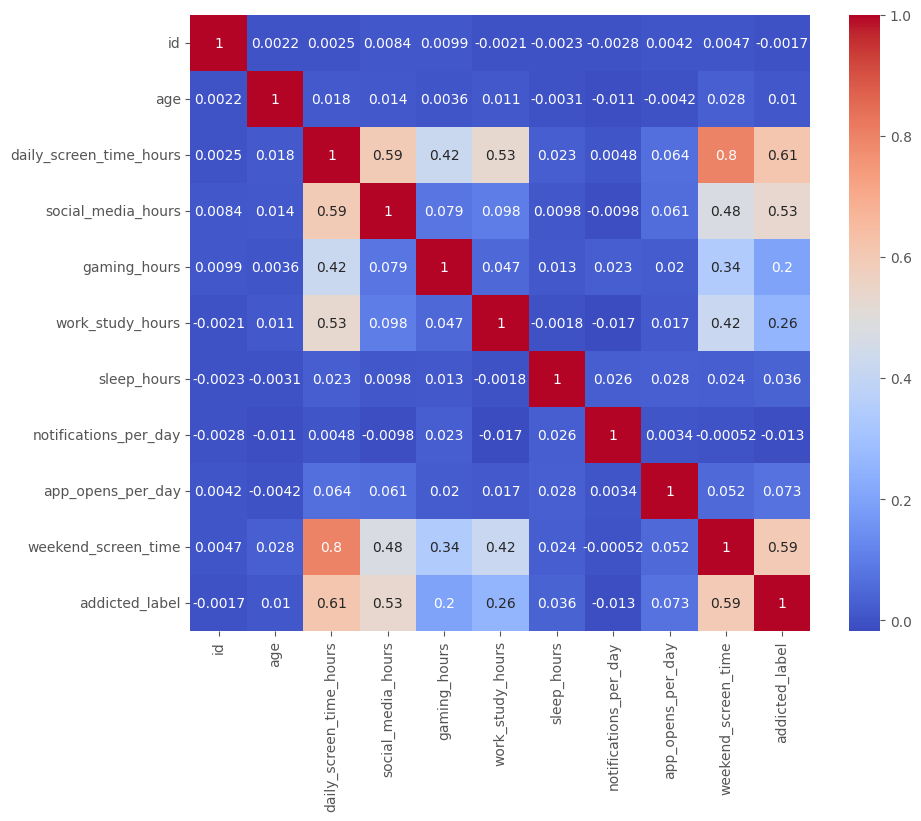

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(
    train.select_dtypes(include=["number"]).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [ ]:
test.head(1)

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
0,691369,30.0,9.34,NaN,0.77,4.09,7.15,153.0,16.0,NaN,Other,Medium,Yes


we are performing EDA

social_media_hours       19.37%
gaming_hours             18.41%
weekend_screen_time      16.17%
daily_screen_time_hours  13.87%
app_opens_per_day        11.83%
notifications_per_day     9.81%
stress_level              8.04%
work_study_hours          7.47%
academic_work_impact      6.50%
sleep_hours               6.38%
gender                    4.14%
age                       4.13%

In [ ]:
catgorical_col= {
    'gender',
    'stress_level',
    'academic_work_impact'
}

for col in catgorical_col:
  print("\n","="*40)
  print(col)
  print(train[col].value_counts(dropna=False))


gender
gender
Male      10593
Other     10513
Female    10499
NaN        1318
Name: count, dtype: int64

stress_level
stress_level
High      10508
Low        9919
Medium     9839
NaN        2657
Name: count, dtype: int64

academic_work_impact
academic_work_impact
Yes    15594
No     15194
NaN     2135
Name: count, dtype: int64


In [ ]:
##doesn't appear to have a strong standalone relationship with the target.
#"Har category mein addiction rate kitna hai?"
for col in catgorical_col:
  print("\n","="*50)
  print(col)
  print(train.groupby(col,dropna=False)["addicted_label"].mean().sort_values(ascending=False))


gender
gender
Male      0.720853
Female    0.702543
Other     0.695710
NaN       0.694761
Name: addicted_label, dtype: float64

stress_level
stress_level
Low       0.708842
High      0.706604
Medium    0.705864
NaN       0.692771
Name: addicted_label, dtype: float64

academic_work_impact
academic_work_impact
Yes    0.710145
No     0.705213
NaN    0.680412
Name: addicted_label, dtype: float64


We calculated relationships between numerical features and addicted_label.

In [ ]:
####"Okay, correlation says screen time matters. But how exactly does addiction probability change as screen time changes?"
train.groupby(
    pd.cut(
        train["daily_screen_time_hours"],
        bins=10
    ),
    observed=False
)["addicted_label"].mean()



,addicted_label
daily_screen_time_hours,
"(0.486, 1.911]",0.253394
"(1.911, 3.322]",0.243061
"(3.322, 4.733]",0.299036
"(4.733, 6.144]",0.360640
"(6.144, 7.555]",0.645515
"(7.555, 8.966]",0.876944
"(8.966, 10.377]",0.988560
"(10.377, 11.788]",0.999750
"(11.788, 13.199]",0.999136


In [ ]:
train.groupby(
    pd.cut(
        train["social_media_hours"],
        bins=10
    ),
    observed=False
)["addicted_label"].mean()

,addicted_label
social_media_hours,
"(-0.00743, 0.743]",0.223602
"(0.743, 1.486]",0.373232
"(1.486, 2.229]",0.651143
"(2.229, 2.972]",0.840635
"(2.972, 3.715]",0.953278
"(3.715, 4.458]",0.984921
"(4.458, 5.201]",0.998706
"(5.201, 5.944]",1.000000
"(5.944, 6.687]",1.000000


In [ ]:
train.groupby(
    pd.cut(
        train["weekend_screen_time"],
        bins=10
    ),
    observed=False
)["addicted_label"].mean()

,addicted_label
weekend_screen_time,
"(0.803, 2.494]",0.340909
"(2.494, 4.168]",0.258671
"(4.168, 5.842]",0.260818
"(5.842, 7.516]",0.351313
"(7.516, 9.19]",0.571456
"(9.19, 10.864]",0.866390
"(10.864, 12.538]",0.986178
"(12.538, 14.212]",0.999704
"(14.212, 15.886]",1.000000


data cleaning

In [ ]:
train = train.dropna(subset=["addicted_label"]).copy()


In [ ]:
train.shape

(32922, 14)

In [ ]:
train.duplicated().sum()

np.int64(0)

In [ ]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,32922.0,16460.500000,9503.907118,0.00,8230.25,16460.50,24690.75,32921.00
age,31560.0,26.656781,5.139550,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,28355.0,7.645064,2.717597,0.50,5.50,7.79,9.82,14.61
social_media_hours,26500.0,2.447898,1.311346,0.00,1.43,2.28,3.34,7.43
gaming_hours,26867.0,1.462854,0.935799,0.00,0.71,1.34,2.10,4.00
work_study_hours,30542.0,2.382781,1.266621,0.01,1.36,2.21,3.24,6.00
sleep_hours,30784.0,6.805166,1.232480,4.50,5.78,6.81,7.84,9.00
notifications_per_day,29656.0,145.750169,66.006227,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,29016.0,102.653157,48.294355,15.00,63.00,104.00,145.00,180.00
weekend_screen_time,27670.0,9.475802,2.854013,0.82,7.28,9.58,11.76,17.56


In [ ]:
categorical_cols = [
    "gender",
    "stress_level",
    "academic_work_impact"
]

for col in categorical_cols:
  print("\n","="*50)
  print(col)
  print(train[col].unique())


gender
['Male' 'Female' 'Other' nan]

stress_level
['Medium' 'Low' 'High' nan]

academic_work_impact
['No' 'Yes' nan]


In [ ]:
x = train.drop(columns=["id", 'addicted_label'])

In [ ]:
missing = train.isnull().sum()
missing_percentage = (missing/len(train)*100).round(2)

missing_table= pd.DataFrame(
    {
        "missing_count": missing,
        "missing_percentage": missing_percentage
    }
)
print(missing_table.sort_values("missing_percentage",ascending=False))

                         missing_count  missing_percentage
social_media_hours                6422               19.51
gaming_hours                      6055               18.39
weekend_screen_time               5252               15.95
daily_screen_time_hours           4567               13.87
app_opens_per_day                 3906               11.86
notifications_per_day             3266                9.92
stress_level                      2656                8.07
work_study_hours                  2380                7.23
sleep_hours                       2138                6.49
academic_work_impact              2134                6.48
age                               1362                4.14
gender                            1317                4.00
id                                   0                0.00
addicted_label                       0                0.00


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x= train.drop(columns=['id', 'addicted_label'])
y = train["addicted_label"]

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

print("x_train",x_train.shape)
print("x_test",x_test.shape)

print("\ntraining target:")

print(y_train.value_counts(normalize=True))

print("\n validation target:")
print(y_test.value_counts(normalize=True))

x_train (26337, 12)
x_test (6585, 12)

training target:
addicted_label
1.0    0.705927
0.0    0.294073
Name: proportion, dtype: float64

 validation target:
addicted_label
1.0    0.705998
0.0    0.294002
Name: proportion, dtype: float64


In [ ]:
numerical_col=[
    "age",
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day",
    "weekend_screen_time"
]

categorical_col = [
    "gender",
    "stress_level",
    "academic_work_impact"
]

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

daily_screen_time_hours

7.2
8.1
NaN
6.5
7.8

median

7.2
8.1
7.8
6.5
7.8

In [ ]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

suppose
gender

Male
Female
NaN
Other

output
Male
Female
Missing
Other

In [ ]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [ ]:
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_col),
    ("cat", categorical_pipeline, categorical_col)
])

In [ ]:
print(preprocessor.transformers)

[('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))]), ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']), ('cat', Pipeline(steps=[('imputer',
                 SimpleImputer(fill_value='missing', strategy='constant')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))]), ['gender', 'stress_level', 'academic_work_impact'])]


In [ ]:
for name, transformer, columns in preprocessor.transformers:
    print(name, type(columns), columns)

num <class 'list'> ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']
cat <class 'list'> ['gender', 'stress_level', 'academic_work_impact']


In [ ]:
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

print("original training shape",x_train.shape)
print(" valid training processed shape", x_train_processed.shape)

print("original testing shape", x_test.shape)
print("valid testing processed shape", x_test_processed.shape)

original training shape (26337, 12)
 valid training processed shape (26337, 20)
original testing shape (6585, 12)
valid testing processed shape (6585, 20)


In [ ]:
from sklearn.linear_model import LogisticRegression

max_iter=1000 kyun?

Logistic Regression optimization se parameters learn karta hai. Kabhi-kabhi default iterations sufficient nahi hote.

In [ ]:
model = LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
model.fit(x_train_processed,y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred_probability = model.predict_proba(x_test_processed)[:, 1]

In [ ]:
y_pred_probability[:10]


array([0.98883209, 0.94020149, 0.4955136 , 0.98967101, 0.93230822,
       0.41136903, 0.43717637, 0.99646608, 0.99321302, 0.9981527 ])

In [ ]:
from sklearn.metrics import roc_auc_score


In [ ]:
auc = roc_auc_score(y_test,y_pred_probability)

In [ ]:
auc

np.float64(0.9081028489197891)

In [ ]:
coefficients = model.coef_[0]

for feature, coefficient in zip(
    preprocessor.get_feature_names_out(),
    coefficients
):
    print(f"{feature:40} {coefficient:.4f}")

num__age                                 0.0040
num__daily_screen_time_hours             0.3499
num__social_media_hours                  1.0580
num__gaming_hours                        -0.1207
num__work_study_hours                    -0.0349
num__sleep_hours                         0.0827
num__notifications_per_day               -0.0009
num__app_opens_per_day                   0.0021
num__weekend_screen_time                 0.3768
cat__gender_Female                       -0.8265
cat__gender_Male                         -0.7845
cat__gender_Other                        -0.8476
cat__gender_missing                      -0.9799
cat__stress_level_High                   -0.8538
cat__stress_level_Low                    -0.8358
cat__stress_level_Medium                 -0.7689
cat__stress_level_missing                -0.9799
cat__academic_work_impact_No             -1.1076
cat__academic_work_impact_Yes            -1.0793
cat__academic_work_impact_missing        -1.2514


In [ ]:
feature_names = preprocessor.get_feature_names_out()
coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    "feature":feature_names,
    "coefficient": coefficients
})
coef_df["abs_coefficient"]= coef_df["coefficient"].abs()

coef_df= coef_df.sort_values(
    "abs_coefficient",
    ascending=False
)

coef_df.head(20)

,feature,coefficient,abs_coefficient
19,cat__academic_work_impact_missing,-1.251410,1.251410
17,cat__academic_work_impact_No,-1.107640,1.107640
18,cat__academic_work_impact_Yes,-1.079327,1.079327
2,num__social_media_hours,1.058008,1.058008
16,cat__stress_level_missing,-0.979917,0.979917
12,cat__gender_missing,-0.979882,0.979882
13,cat__stress_level_High,-0.853799,0.853799
11,cat__gender_Other,-0.847568,0.847568
14,cat__stress_level_Low,-0.835766,0.835766
9,cat__gender_Female,-0.826453,0.826453


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

Why only these?

Because EDA gave us evidence that these features have strong curved relationships. We don't want to blindly create polynomial features for everything.

In [ ]:
poly_col = [
    "social_media_hours",
    "daily_screen_time_hours",
    "weekend_screen_time"
]

In [ ]:
poly_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=3,include_bias=False))
])

In [ ]:
normal_numeric_cols = [
    "age",
    "gaming_hours",
    "work_study_hours",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day"
]

In [ ]:
train.head(1)

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1.0


In [ ]:
poly_preprocessor = ColumnTransformer([
    ("poly_num",poly_pipeline,poly_col),
    ("num",numerical_pipeline,normal_numeric_cols),
    ("cat", categorical_pipeline,categorical_col)
])

In [ ]:
x_train_poly= poly_preprocessor.fit_transform(x_train)
x_test_poly= poly_preprocessor.transform(x_test)

In [ ]:
poly_model = LogisticRegression(
    max_iter= 2000,
    random_state = 42
)

poly_model.fit(x_train_poly,y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=2000, random_state=42)

In [ ]:
y_pred_poly = poly_model.predict_proba(x_test_poly)[:,1]

In [ ]:
poly_auc = roc_auc_score(y_test,y_pred_poly)

In [ ]:
print("baseline auc ",auc)
print("polynomial auc ", poly_auc)

baseline auc  0.9081028489197891
polynomial auc  0.921124844230253


cross validation

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

In [ ]:
skf = StratifiedKFold(
    n_splits = 5,
    shuffle = True,
    random_state = 42
)

In [ ]:
poly_preprocessor.fit_transform(x_train)

array([[ 1.45,  4.56,  6.78, ...,  0.  ,  1.  ,  0.  ],
       [ 4.85, 11.67, 12.48, ...,  0.  ,  1.  ,  0.  ],
       [ 2.88,  7.06, 10.11, ...,  1.  ,  0.  ,  0.  ],
       ...,
       [ 2.27,  7.8 ,  9.58, ...,  1.  ,  0.  ,  0.  ],
       [ 2.62,  7.25,  9.53, ...,  0.  ,  1.  ,  0.  ],
       [ 3.6 ,  9.73, 10.82, ...,  0.  ,  1.  ,  0.  ]])

In [ ]:
from sklearn.pipeline import Pipeline

In [ ]:
cv_pipeline = Pipeline([
    ("preprocessor", poly_preprocessor),
    ("model",LogisticRegression(max_iter = 2000, random_state=42))
])

In [ ]:
cv_score = []

for fold,(train_idx, valid_idx) in enumerate(
    skf.split(x_train,y_train),1
):
  x_tr = x_train.iloc[train_idx]
  x_val = x_train.iloc[valid_idx]

  y_tr = y_train.iloc[train_idx]
  y_val = y_train.iloc[valid_idx]

  cv_pipeline.fit(x_tr,y_tr)

  pred_proba = cv_pipeline.predict_proba(x_val)[:,1]
  score = roc_auc_score(y_val,pred_proba)

  cv_score.append(score)

  print(f"Fold {fold} Roc_Auc {score:.5f}")



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 1 Roc_Auc 0.92407


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 2 Roc_Auc 0.92559


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 3 Roc_Auc 0.92979


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 4 Roc_Auc 0.92580
Fold 5 Roc_Auc 0.92610


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
print("mean of Roc_Auc:",np.mean(cv_score))
print("std of Roc_Auc:",np.std(cv_score))


mean of Roc_Auc: 0.9262707406562548
std of Roc_Auc: 0.0018954125347348339


What this tells us

Our polynomial Logistic Regression is not only good, but very stable across the 5 folds.

Why Tree Models?

Logistic Regression assumes a mathematical relationship between features and the target



we will see if our tree based model is able to beet the above

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_preprocessor = ColumnTransformer([
    ("num",numerical_pipeline,numerical_col),
    ("cat",categorical_pipeline,categorical_col)
])

In [ ]:
rf_pipeline = Pipeline([
    ("preprocessor",rf_preprocessor),
    ("model",RandomForestClassifier(n_estimators=300,random_state=42,n_jobs=-1))
])

n_estimators=300
It means:

300 decision trees

will be created.

n_jobs=-1 means:

Use all available CPU cores.

In [ ]:
# now train it
rf_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['age',
                                                   'daily_screen_time_hours',
                                                   'social_media_hours',
                                                   'gaming_hours',
                                                   'work_study_hours',
                                                   'sleep_hours',
                                                   'notifications_per_day',
                                                   'app_opens_per_day',
                                                   'weekend_screen_time']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'stress_level',
                                                   'academic_work_impact'])])),
                ('model',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [ ]:
rf_pred = rf_pipeline.predict_proba(x_test)[:,1]

In [ ]:
rf_auc = roc_auc_score(y_test,rf_pred)

print("Random forest roc_auc is : ",rf_auc)

Random forest roc_auc is :  0.9320363927904162


Random Forest has beaten our previous model.

In [ ]:
# now applying cross validation on random forest

rf_cv_score = []

for fold , (train_idx,valid_idx) in enumerate(
    skf.split(x_train, y_train),1
):

  x_tr = x_train.iloc[train_idx]
  x_val = x_train.iloc[valid_idx]

  y_tr = y_train.iloc[train_idx]
  y_val = y_train.iloc[valid_idx]

  rf_pipeline.fit(x_tr, y_tr)

  pred_proba = rf_pipeline.predict_proba(x_val)[:,1]

  score = roc_auc_score(y_val, pred_proba)

  rf_cv_score.append(score)

  print(f"fold {fold}, Roc_auc: {score:.5f}")

fold 1, Roc_auc: 0.93250
fold 2, Roc_auc: 0.93130
fold 3, Roc_auc: 0.93751
fold 4, Roc_auc: 0.93481
fold 5, Roc_auc: 0.93574


In [ ]:
print("mean Roc_auc:",np.mean(rf_cv_score))
print("standard roc_auc:", np.std(rf_cv_score))

mean Roc_auc: 0.9343721547046071
standard roc_auc: 0.002229901784092498


In [ ]:
feature_names = rf_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

importances = rf_pipeline.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance":importances
})

importance_df = importance_df.sort_values(
    "importance", ascending=False
)

importance_df.head(20)

,feature,importance
1,num__daily_screen_time_hours,0.232521
8,num__weekend_screen_time,0.203110
2,num__social_media_hours,0.179671
4,num__work_study_hours,0.073937
3,num__gaming_hours,0.060295
7,num__app_opens_per_day,0.051519
5,num__sleep_hours,0.050287
6,num__notifications_per_day,0.049265
0,num__age,0.036027
17,cat__academic_work_impact_No,0.006756


This result gives us a very clear picture of what the Random Forest is learning.

In [ ]:
x = train.drop(columns=["addicted_label"])
y = train["addicted_label"]

x_kaggel_test = test.copy()

In [ ]:
rf_pipeline.fit(x,y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['age',
                                                   'daily_screen_time_hours',
                                                   'social_media_hours',
                                                   'gaming_hours',
                                                   'work_study_hours',
                                                   'sleep_hours',
                                                   'notifications_per_day',
                                                   'app_opens_per_day',
                                                   'weekend_screen_time']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'stress_level',
                                                   'academic_work_impact'])])),
                ('model',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [ ]:
test_prediction = rf_pipeline.predict_proba(x_kaggel_test)[:,1]

In [ ]:
submission = pd.DataFrame({
    "id": test["id"],
    "addicted_label": test_prediction
})

In [ ]:
submission.head()

,id,addicted_label
0,691369,0.960000
1,691370,0.806667
2,691371,0.973333
3,691372,0.966667
4,691373,0.980000


In [ ]:
submission.shape

(33272, 2)

In [ ]:
submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33272 entries, 0 to 33271
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              33272 non-null  int64  
 1   addicted_label  33272 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 520.0 KB


In [ ]:
submission.columns

Index(['id', 'addicted_label'], dtype='object')

In [ ]:
submission.isna().sum()

,0
id,0
addicted_label,0


In [ ]:
submission["addicted_label"].min()

0.0033333333333333335

In [ ]:
submission["addicted_label"].max()

1.0

In [ ]:
submission.to_csv("submission.csv",index=False)

In [ ]:
submission = pd.read_csv("/content/submission.csv")

In [ ]:
submission.head()

,id,addicted_label
0,691369,0.960000
1,691370,0.806667
2,691371,0.973333
3,691372,0.966667
4,691373,0.980000


In [ ]:
print(len(test))
print(len(submission))

print(submission['id'].equals(test['id']))

33272
33272
True


In [ ]:
print("train:", train.shape)
print("test:", test.shape)

print("submission:", submission.shape)

print("test ID min:", test["id"].min())
print("test ID max:", test["id"].max())

print("submission ID min:", submission["id"].min())
print("submission ID max:", submission["id"].max())

train: (32922, 14)
test: (33272, 13)
submission: (33272, 2)
test ID min: 691369
test ID max: 724640
submission ID min: 691369
submission ID max: 724640


In [ ]:
print(test.head())
print(test.tail())

       id   age  daily_screen_time_hours  social_media_hours  gaming_hours  \
0  691369  30.0                     9.34                 NaN          0.77   
1  691370   NaN                      NaN                1.91           NaN   
2  691371  26.0                     8.48                3.64           NaN   
3  691372  20.0                     8.37                2.99          1.69   
4  691373  25.0                     8.25                4.02          1.21   

   work_study_hours  sleep_hours  notifications_per_day  app_opens_per_day  \
0              4.09         7.15                  153.0               16.0   
1              1.20         8.67                  239.0              148.0   
2              3.39         7.47                  106.0              123.0   
3              2.53         5.45                  178.0               55.0   
4              2.32         8.46                   63.0               86.0   

   weekend_screen_time  gender stress_level academic_work_impa

In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file in ["train.csv", "test.csv"]:
            print(os.path.join(root, file))

/content/train.csv
/content/test.csv


In [ ]:
train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")

print("train:", train.shape)
print("test:", test.shape)

train: (691369, 14)
test: (296302, 13)


In [ ]:
print(type(train))
print(type(test))

print("TRAIN SHAPE =", train.shape)
print("TEST SHAPE  =", test.shape)

print("\nTRAIN COLUMNS:")
print(train.columns.tolist())

print("\nTEST COLUMNS:")
print(test.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
TRAIN SHAPE = (691369, 14)
TEST SHAPE  = (296302, 13)

TRAIN COLUMNS:
['id', 'age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level', 'academic_work_impact', 'addicted_label']

TEST COLUMNS:
['id', 'age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level', 'academic_work_impact']


In [ ]:
display(train.head())
display(test.head())

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
0,691369,30.0,9.34,NaN,0.77,4.09,7.15,153.0,16.0,NaN,Other,Medium,Yes
1,691370,NaN,NaN,1.91,NaN,1.20,8.67,239.0,148.0,10.68,Female,High,No
2,691371,26.0,8.48,3.64,NaN,3.39,7.47,106.0,123.0,NaN,Male,NaN,No
3,691372,20.0,8.37,2.99,1.69,2.53,5.45,178.0,55.0,9.88,Male,High,Yes
4,691373,25.0,8.25,4.02,1.21,2.32,8.46,63.0,86.0,10.72,Male,Low,No


In [ ]:
print("train has target:", "addicted_label" in train.columns)
print("test has target:", "addicted_label" in test.columns)

train has target: True
test has target: False


In [ ]:
print("train rows:", len(train))
print("test rows:", len(test))

print("train ID range:", train["id"].min(), train["id"].max())
print("test ID range:", test["id"].min(), test["id"].max())

train rows: 691369
test rows: 296302
train ID range: 0 691368
test ID range: 691369 987670


In [ ]:
print(test["id"].nunique())
print(test["id"].duplicated().sum())

296302
0


In [ ]:
X = train.drop(columns=["addicted_label"])
y = train["addicted_label"]

X_kaggle_test = test.copy()

print(X.shape)
print(y.shape)
print(X_kaggle_test.shape)

(691369, 13)
(691369,)
(296302, 13)


In [ ]:
print(y.value_counts())
print(y.value_counts(normalize=True))

addicted_label
1    490474
0    200895
Name: count, dtype: int64
addicted_label
1    0.709424
0    0.290576
Name: proportion, dtype: float64


In [ ]:
import pandas as pd

check = pd.read_csv("submission.csv")

print("File rows:", len(check))
print(check.shape)
print(check.head())

File rows: 33272
(33272, 2)
       id  addicted_label
0  691369        0.960000
1  691370        0.806667
2  691371        0.973333
3  691372        0.966667
4  691373        0.980000


In [ ]:
print("Test rows:", len(test))
print("Prediction rows:", len(test_prediction))

Test rows: 296302
Prediction rows: 33272


In [ ]:
test_predictions = rf_pipeline.predict_proba(
    test
)[:, 1]

In [ ]:
print("Test rows:", len(test))
print("Prediction rows:", len(test_predictions))

Test rows: 296302
Prediction rows: 296302


In [ ]:
submission = pd.DataFrame({
    "id": test["id"].values,
    "addicted_label": test_predictions
})

In [ ]:
print(submission.shape)
display(submission.head())

(296302, 2)


,id,addicted_label
0,691369,0.960000
1,691370,0.806667
2,691371,0.973333
3,691372,0.966667
4,691373,0.980000


In [ ]:
submission.to_csv("submission.csv", index=False)

In [ ]:
check = pd.read_csv("submission.csv")

print("Saved file shape:", check.shape)
print("Rows:", len(check))
print("IDs match:", check["id"].equals(test["id"]))
print("Missing values:")
print(check.isna().sum())

Saved file shape: (296302, 2)
Rows: 296302
IDs match: True
Missing values:
id                0
addicted_label    0
dtype: int64
